In [144]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [145]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device('cuda')

# include parent dir in python path
sys.path.append('/media/carsen/ssd1/github/oneshot')
from utils import data, metrics

data_path = '/media/carsen/ssd1/github/oneshot/data'
# data_path  = '/home/carsen/dm11_cluster/fengtongd/Desktop/approxineuro/data'
# change path to your own dm11 path
img_root = '/home/carsen/dm11_pachitariu/data/STIM/'
weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights'
# weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/approxineuro/weights'

# fullmodel (medial + V1 trained together)
- FEV and FEVE plot 
- get the neruon indexes for medial and V1
- compare the pooling size of these two areas
- visualize the first layer
- save the indexes to the data file for further training the separate models

In [146]:
# mouse 7 and 8
# load data

mouse_id = 12
depth_separable = True
pool = True
clamp = True
use_30k = False # use all data recorded (>30k) or only 30k, performance will decrease if use only 30k.

# load images
crop = True
img = data.load_images(img_root, file=os.path.join(img_root, data.img_file_name[mouse_id]), crop=crop)# xrange=[0,130])
nimg, Ly, Lx = img.shape
print('img: ', img.shape, img.min(), img.max(), img.dtype)

# load neurons
fname = '%s_nat30k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, fixtrain=use_30k)
n_stim, n_neurons = spks.shape
print('spks: ', spks.shape, spks.min(), spks.max())
print('spks_rep_all: ', len(spks_rep_all), spks_rep_all[0].shape)
print('istim_train: ', istim_train.shape, istim_train.min(), istim_train.max())
print('istim_test: ', istim_test.shape, istim_test.min(), istim_test.max())

# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
print('itrain: ', itrain.shape, itrain.min(), itrain.max())
print('ival: ', ival.shape, ival.min(), ival.max())
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)

# ineur = np.arange(0, n_neurons) #np.arange(0, n_neurons, 5)
from utils import metrics
test_fev = metrics.fev_nan(spks_rep_all)
print('FEV (test): ', np.mean(test_fev))

ineur = np.where(test_fev > 0.1)[0] #np.arange(0, n_neurons, 5) #np.where(test_fev > 0.05)[0] #np.arange(0, n_neurons) #np.arange(0, 100)
# ineur = np.arange(0, n_neurons) #np.where(test_fev > 0.05)[0] #np.arange(0, n_neurons) #np.arange(0, 100)
img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)
print('img_test: ', img_test.shape, img_test.min(), img_test.max())
input_Ly, input_Lx = img_test.shape[-2:]


spks_train = torch.from_numpy(spks[itrain][:,ineur])
spks_val = torch.from_numpy(spks[ival][:,ineur]) 
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]
xpos = xpos[ineur]
ypos = ypos[ineur]
print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())


raw image shape:  (68032, 66, 264)
cropped image shape:  (68032, 66, 130)
image mean:  126.71216
image std:  61.42324
img:  (68032, 66, 130) -2.062935 2.088588 float32

loading activities from /media/carsen/ssd1/github/oneshot/data/FX43_nat30k_2025_05_19.npz
spks:  (29500, 4180) -1.110223e-16 5.6614475
spks_rep_all:  500 (10, 4180)
istim_train:  (29500,) 532 30031
istim_test:  (500,) 32 531

splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (26550,)
ival:  (2950,)
itrain:  (26550,) 1 29499
ival:  (2950,) 0 29490

normalizing neural data...
FEV (test):  0.14340354963175775
img_test:  torch.Size([500, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
spks_train:  torch.Size([26550, 2341]) tensor(-8.1106e-16) tensor(30.9300)
spks_val:  torch.Size([2950, 2341]) tensor(0.) tensor(28.9629)


In [147]:
# load the models and get FEVE
# 64, 16-64, 16-64-64, 16-64-64-64 model result
from utils import model_builder

lrs = [0.006, 0.003, 0.003, 0.003]
weight_decay_cores = [0.1, 0.001, 0.003, 0.06]
l2_readouts = [0.001, 0.001, 0.1, 0.1]

nlayers = 2
nconv1 = 16
nconv2 = 64

model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, input_Ly=input_Ly, input_Lx=input_Lx)
model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='', ineuron=len(ineur), crop=crop)
# weight_path = './checkpoints/'
model_path = os.path.join(weight_path, 'fullmodel', data.mouse_names[mouse_id], model_name)
model = model.to(device)

model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

# test model
from utils import model_trainer
test_pred = model_trainer.test_epoch(model, img_test)

input shape of readout:  (64, 33, 65)
model name:  FX43_051925_2layer_16_64_clamp_sensorium_depthsep_pool_nneurons_2341.pt


RuntimeError: Error(s) in loading state_dict for Encoder:
	size mismatch for readout.Wx: copying a param with shape torch.Size([2341, 1, 132]) from checkpoint, the shape in current model is torch.Size([2341, 1, 65]).

In [ ]:
test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
ivalid = np.where(test_fev > 0.15)[0]
print(len(ivalid), ' neurons with FEV > 0.15')
print('FEVE (test): ', np.mean(test_feve[ivalid]))

306  neurons with FEV > 0.15
FEVE (test):  0.762740785506222


In [ ]:
from utils.model_utils import weight_bandwidth
x_pixel_ratio = 0.5
y_pixel_ratio = 0.5
Wx = model.readout.Wx.cpu().detach().numpy()
Wy = model.readout.Wy.cpu().detach().numpy()
# outer product of Wx and Wy
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
Wx = Wx.squeeze()
Wy = Wy.squeeze()
NN = Wx.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
centerpos_Wx = np.zeros(NN)
centerpos_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i], centerpos_Wx[i] = weight_bandwidth(Wx[i, :], return_peak=True)
    bandwidth_Wy[i], centerpos_Wy[i] = weight_bandwidth(Wy[i, :], return_peak=True)

rf_size = bandwidth_Wx * bandwidth_Wy
rf_size = np.sqrt(rf_size* (270/264)*(65/66)) * 2 
print(f'average rf size: {np.mean(rf_size):.2f}')
xpos_model = np.argmax(Wx.squeeze(), axis=1) 
ypos_model = np.argmax(Wy.squeeze(), axis=1) 
xpos_visual = centerpos_Wx*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
ypos_visual = centerpos_Wy*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
# if mouse_id == 5: xpos_visual += (46*270/264) # xrange of mouse 6 is 46-176
xpos_plot = xpos / x_pixel_ratio
ypos_plot = ypos / y_pixel_ratio

average rf size: 18.42


In [ ]:
# separate neurons
hmax_angle = 50
if mouse_id == 5:
    point1 = [-200, 0]
    point2 = [-500, 600]
if mouse_id == 7:
    point1 = [-650, 150]
    point2 = [-480, 420]
elif mouse_id == 8:
    point1 = [-700, 0]
    point2 = [-400, 420]
if mouse_id == 10:
    point1 = [-600, 0]
    point2 = [0, 800]
    hmax_angle = 88
if mouse_id == 11:
    hmax_angle = 88
if mouse_id <= 10:
    a = (point1[1] - point2[1]) / (point1[0] - point2[0])
    b = point1[1] - a * point1[0]
    imedial = np.where(xpos_plot >= -a * ypos_plot + b)[0]
    iv1 = np.where(xpos_plot < -a * ypos_plot + b)[0]
else:
    area_names = ['PM','AM','','RL','','LM','AL','','V1','RSP']
    region_names = ['V1', 'medial', 'anterior', 'lateral', 'all']
    aligned_path = '/media/carsen/ssd1/github/retinotopy/aligned'
    db = data.db[mouse_id]
    dpath = os.path.join(aligned_path, f"{db['mname']}_{db['datexp']}_{db['blk']}.npz")
    aligned_data = np.load(dpath)
    iregion = aligned_data['iregion']
    iarea = aligned_data['iarea'][ineur]
    imedial = np.where(iarea == 0)[0]
    iv1 = np.where(iarea == 8)[0]

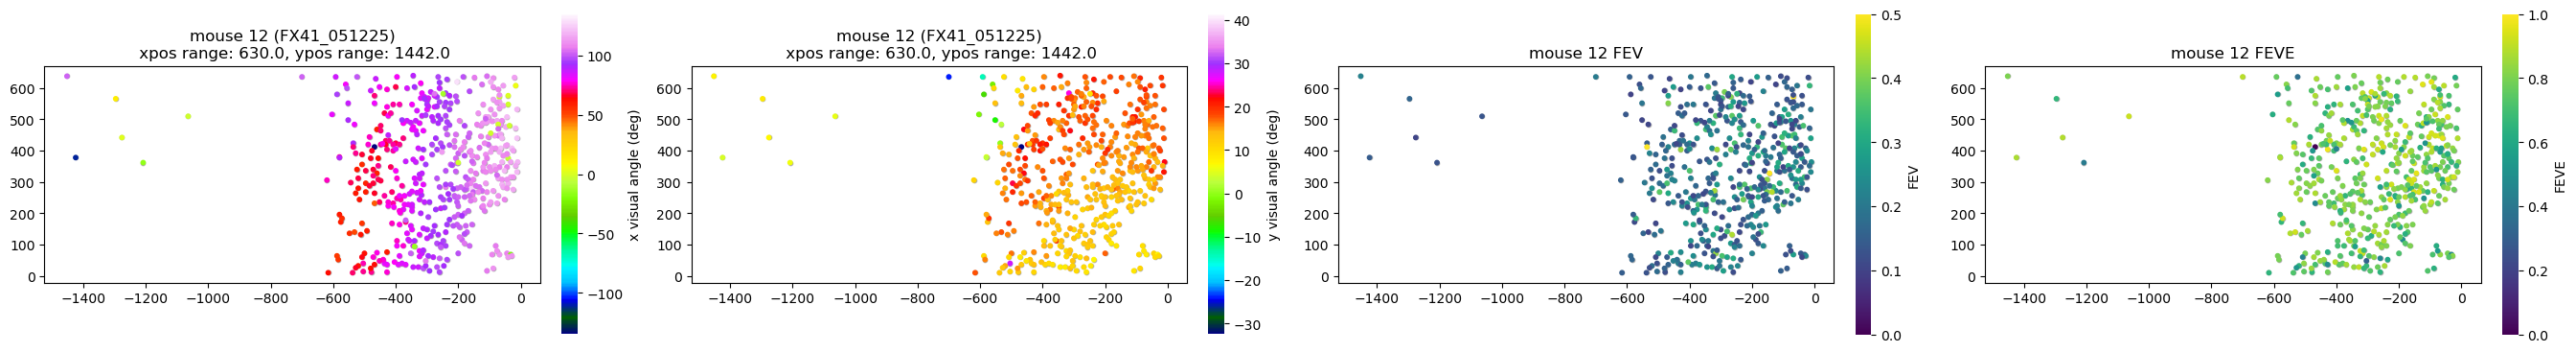

In [ ]:
valid_idxes = np.where(test_fev > 0.1)[0]
# xpos_visual = xmax*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
# ypos_visual = ymax*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
# xpos_plot, ypos_plot  = xpos/pix_res[0], ypos/pix_res[1]
vmin_x = -135
vmax_x = 270 * (hmax_angle/88)-135
vmin_y = -32.5
vmax_y = 65*(25/22)-32.5
plot_boundary = False
fig, ax = plt.subplots(1, 4, figsize=(27, 5))
ax[0].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos_plot, xpos_plot, c=xpos_visual, s=10, cmap='gist_ncar', vmin=vmin_x, vmax=vmax_x, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[0].set_aspect('equal', adjustable='box')

# ax.set_axis_off()
# fig.savefig(f'./outputs/{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_xpos_visual.png', dpi=300, bbox_inches='tight')
# plt.close(fig)
ax[1].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[1].scatter(-ypos_plot, xpos_plot, c=ypos_visual, s=10, cmap='gist_ncar', vmin=vmin_y, vmax=vmax_y, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')
ax[1].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[1].set_aspect('equal', adjustable='box')
# ax[1].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

ax[2].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[2].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=0.5)
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
ax[2].set_title(f'mouse {mouse_id+1} FEV', loc='center')
ax[2].set_aspect('equal', adjustable='box')
# ax[2].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

ax[3].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[3].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[3], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
ax[3].set_title(f'mouse {mouse_id+1} FEVE', loc='center')
ax[3].set_aspect('equal', adjustable='box')

if plot_boundary:
    for i in range(4):
        ax[i].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)
# ax[3].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)
plt.tight_layout()


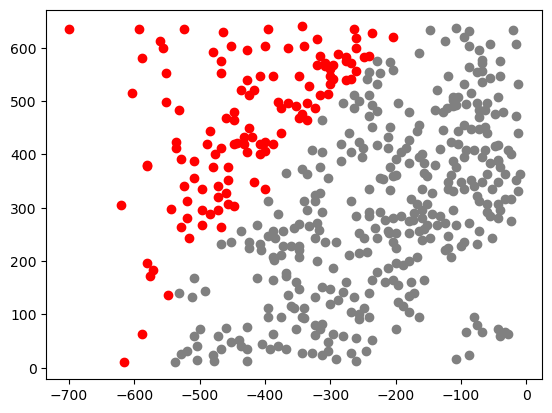

In [ ]:
plt.scatter(-ypos_plot[iv1], xpos_plot[iv1], c='gray')
plt.scatter(-ypos_plot[imedial], xpos_plot[imedial], c='red')

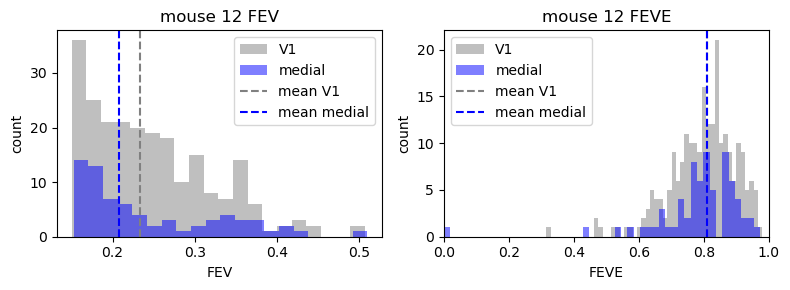

In [ ]:
# distribution of FEV and FEVE in medial and V1
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
iv1 = np.intersect1d(iv1, ivalid)
imedial = np.intersect1d(imedial, ivalid)
ax[0].hist(test_fev[iv1], bins=20, alpha=0.5, label='V1', color='gray')
ax[0].hist(test_fev[imedial], bins=20, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[0].axvline(np.median(test_fev[iv1]), color='gray', linestyle='--', label='mean V1')
ax[0].axvline(np.median(test_fev[imedial]), color='blue', linestyle='--', label='mean medial')
ax[0].set_xlabel('FEV')
ax[0].set_ylabel('count')
ax[0].set_title(f'mouse {mouse_id+1} FEV')
ax[0].legend()
ax[1].hist(test_feve[iv1], bins=50, alpha=0.5, label='V1', color='gray')
ax[1].hist(test_feve[imedial], bins=50, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[1].axvline(np.median(test_feve[iv1]), color='gray', linestyle='--', label='mean V1')
ax[1].axvline(np.median(test_feve[imedial]), color='blue', linestyle='--', label='mean medial')
ax[1].set_xlabel('FEVE')
ax[1].set_ylabel('count')
ax[1].set_title(f'mouse {mouse_id+1} FEVE')
ax[1].legend()
ax[1].set_xlim([0,1])
plt.tight_layout()

In [ ]:
# load the models and get FEVE
# 64, 16-64, 16-64-64, 16-64-64-64 model result
from utils import model_builder
nlayers = 2
feve_all = []
for nlayers in [1, 2, 3, 4]:
    if nlayers == 1:
        nconv1 = 64
    else:
        nconv1 = 16
    weight_decay_core = weight_decay_cores[nlayers-1]
    model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, input_Ly=input_Ly, input_Lx=input_Lx)
    model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='', ineuron=len(ineur), crop=crop)
    # weight_path = './checkpoints/'
    model_path = os.path.join(weight_path, 'fullmodel', data.mouse_names[mouse_id], model_name)
    model = model.to(device)

    model.load_state_dict(torch.load(model_path))
    print('loaded model', model_path)

    # test model
    from utils import model_trainer
    test_pred = model_trainer.test_epoch(model, img_test)

    test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
    print('FEVE (test): ', np.mean(test_feve))

    feve_all.append(test_feve)

input shape of readout:  (64, 33, 132)
model name:  FX41_051225_1layer_64_clamp_sensorium_depthsep_pool_nocrop_nneurons_476.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_051225_1layer_64_clamp_sensorium_depthsep_pool_nocrop_nneurons_476.pt
FEVE (test):  0.6035760591572081
input shape of readout:  (64, 33, 132)
model name:  FX41_051225_2layer_16_64_clamp_sensorium_depthsep_pool_nocrop_nneurons_476.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_051225_2layer_16_64_clamp_sensorium_depthsep_pool_nocrop_nneurons_476.pt
FEVE (test):  0.7409210648652764
input shape of readout:  (64, 33, 132)
model name:  FX41_051225_3layer_16_64_64_clamp_sensorium_depthsep_pool_nocrop_nneurons_476.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/fullmodel/FX41/FX41_051225_3layer_16_64_64_clamp_sensorium_depthsep_pool_nocrop_nneurons_476.pt
FEVE (test):  0.763529908

In [ ]:
print(f'FEV(medail): {np.mean(test_fev[imedial]):.2f}, FEV(V1): {np.mean(test_fev[iv1]):.2f}')

FEV(medail): 0.24, FEV(V1): 0.25


FEV(medail): 0.24, FEV(V1): 0.25, FEV(V1, FEVE<0.15): 0.11


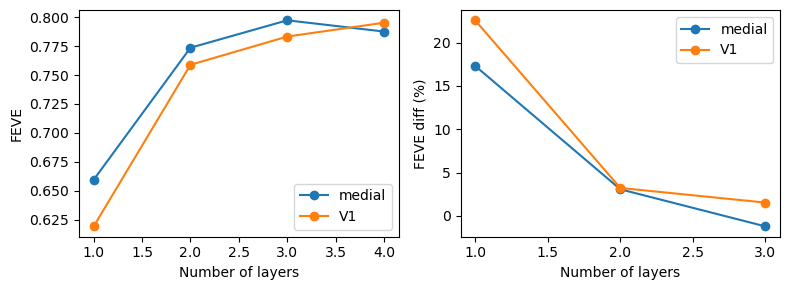

In [ ]:
# plot the FEVE change with the number of layers (separate medial and V1)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
# ivalid = np.where(test_fev > 0.1)[0]
imedial_valid = np.intersect1d(imedial, ivalid)
iv1_valid = np.intersect1d(iv1, ivalid)
feve_all = np.array(feve_all)
ilow_v1 = np.where((test_fev>0.01) & (test_fev<0.12))[0]
print(f'FEV(medail): {np.mean(test_fev[imedial_valid]):.2f}, FEV(V1): {np.mean(test_fev[iv1_valid]):.2f}, FEV(V1, FEVE<0.15): {np.mean(test_fev[ilow_v1]):.2f}')

feve_medial = np.mean(feve_all[:, imedial_valid], axis=1)
feve_v1 = np.mean(feve_all[:, iv1_valid], axis=1)
feve_low_v1 = np.mean(feve_all[:, ilow_v1], axis=1)

ax[0].plot([1, 2, 3, 4], feve_medial, label='medial', marker='o')
ax[0].plot([1, 2, 3, 4], feve_v1, label='V1', marker='o')
# ax[0].plot([1, 2, 3, 4], feve_low_v1, label='V1 (FEVE<0.17)', marker='o')
ax[0].set_xlabel('Number of layers')
ax[0].set_ylabel('FEVE')
ax[0].legend()

# plot the diff of FEVE between each neighboring layers
feve_diff = np.diff(feve_all, axis=0)
feve_diff_medial = np.mean(feve_diff[:, imedial_valid], axis=1) / feve_medial[:-1] * 100
feve_diff_v1 = np.mean(feve_diff[:, iv1_valid], axis=1) / feve_v1[:-1] * 100

ax[1].plot([1, 2, 3], feve_diff_medial, label='medial', marker='o')
ax[1].plot([1, 2, 3], feve_diff_v1, label='V1', marker='o')
ax[1].set_xlabel('Number of layers')
ax[1].set_ylabel('FEVE diff (%)')
ax[1].legend()
plt.tight_layout()

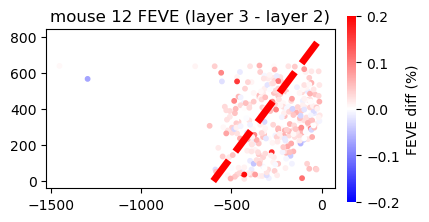

In [ ]:
ilayer1 = 1
ilayer2 = 2
feve_diff = (feve_all[ilayer2] - feve_all[ilayer1])

# ivalid = np.where(feve_all[0] < 0.05)[0]
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = [ax]
sc = ax[0].scatter(-ypos_plot[ivalid], xpos_plot[ivalid], s=10, c=feve_diff[ivalid], cmap='bwr', vmin=-0.2, vmax=0.2)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE diff (%)')
ax[0].set_title(f'mouse {mouse_id+1} FEVE (layer {ilayer2+1} - layer {ilayer1+1})', loc='center')
ax[0].set_aspect('equal', adjustable='box')
ax[0].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

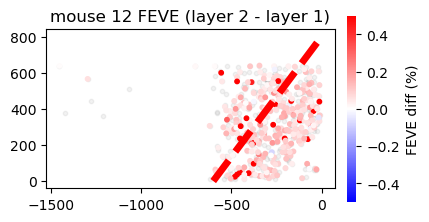

In [ ]:
ilayer1 = 0
ilayer2 = 1
feve_diff = (feve_all[ilayer2] - feve_all[ilayer1])

# ivalid = np.where(feve_all[0] < 0.05)[0]
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = [ax]
ax[0].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.1)
sc = ax[0].scatter(-ypos_plot[ivalid], xpos_plot[ivalid], s=10, c=feve_diff[ivalid], cmap='bwr', vmin=-0.5, vmax=0.5)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE diff (%)')
ax[0].set_title(f'mouse {mouse_id+1} FEVE (layer {ilayer2+1} - layer {ilayer1+1})', loc='center')
ax[0].set_aspect('equal', adjustable='box')
ax[0].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

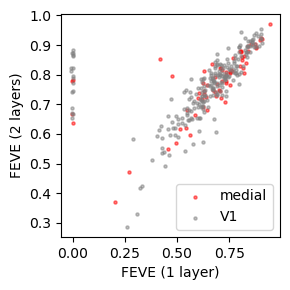

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax = [ax]
ilayer1 = 0
ilayer2 = 1
ax[0].scatter(feve_all[ilayer1, imedial_valid], feve_all[ilayer2, imedial_valid], s=5, c='red', alpha=0.5, label='medial')
ax[0].scatter(feve_all[ilayer1, iv1_valid], feve_all[ilayer2, iv1_valid], s=5, c='gray', alpha=0.5, label='V1')
ax[0].set_xlabel(f'FEVE ({ilayer1+1} layer)')
ax[0].set_ylabel(f'FEVE ({ilayer2+1} layers)')
ax[0].legend()
# ax[0].set_xlim([-0.05,1])
# ax[0].set_ylim([0,1])
plt.tight_layout()

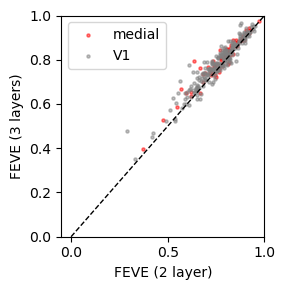

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax = [ax]
ilayer1 = 1
ilayer2 = 2
imedial_valid = np.intersect1d(imedial, ivalid)
iv1_valid = np.intersect1d(iv1, ivalid)
ax[0].scatter(feve_all[ilayer1, imedial_valid], feve_all[ilayer2, imedial_valid], s=5, c='red', alpha=0.5, label='medial')
ax[0].scatter(feve_all[ilayer1, iv1_valid], feve_all[ilayer2, iv1_valid], s=5, c='gray', alpha=0.5, label='V1')
ax[0].set_xlabel(f'FEVE ({ilayer1+1} layer)')
ax[0].set_ylabel(f'FEVE ({ilayer2+1} layers)')
ax[0].legend()
ax[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
ax[0].set_xlim([-0.05,1])
ax[0].set_ylim([0,1])
plt.tight_layout()

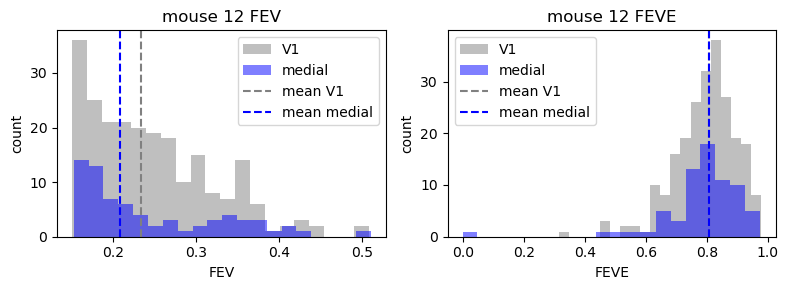

In [ ]:
# distribution of FEV and FEVE in medial and V1
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].hist(test_fev[iv1_valid], bins=20, alpha=0.5, label='V1', color='gray')
ax[0].hist(test_fev[imedial_valid], bins=20, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[0].axvline(np.median(test_fev[iv1_valid]), color='gray', linestyle='--', label='mean V1')
ax[0].axvline(np.median(test_fev[imedial_valid]), color='blue', linestyle='--', label='mean medial')
ax[0].set_xlabel('FEV')
ax[0].set_ylabel('count')
ax[0].set_title(f'mouse {mouse_id+1} FEV')
ax[0].legend()
ax[1].hist(test_feve[iv1_valid], bins=20, alpha=0.5, label='V1', color='gray')
ax[1].hist(test_feve[imedial_valid], bins=20, alpha=0.5, label='medial', color='blue')
# plot the mean and std
ax[1].axvline(np.median(test_feve[iv1_valid]), color='gray', linestyle='--', label='mean V1')
ax[1].axvline(np.median(test_feve[imedial_valid]), color='blue', linestyle='--', label='mean medial')
ax[1].set_xlabel('FEVE')
ax[1].set_ylabel('count')
ax[1].set_title(f'mouse {mouse_id+1} FEVE')
ax[1].legend()
plt.tight_layout()

In [ ]:
feve_medial[:-1] 

array([0.6594685537115383, 0.7736521305918229, 0.7973675136350548],
      dtype=object)

# medial model
- compare FEVE with the fullmodel and the medial model
- visualize the first layer
- Does increase the #layer change the FEVE? try 64x64 model, 64x64x64 model and 64x64x64x64 model
- also the #kernels change the FEVE? compare the 16-320 vs 64x64 model